In [2]:
# [CELL 1] SYSTEM SETUP & LIBRARIES
# We need yfinance to pull real-world stock market data from the NSE (National Stock Exchange)
!pip install yfinance --quiet

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make our graphs look professional and "Hedge-Fund" style
plt.style.use('dark_background')
sns.set_context("paper", font_scale=1.2)

print("✅ Cell 1 Complete: All systems go! Libraries are locked and loaded.")

✅ Cell 1 Complete: All systems go! Libraries are locked and loaded.


In [3]:
# [CELL 2] MARKET DATA INGESTION ENGINE (UPDATED FIX)
def get_real_market_data():
    print("Fetching last 15 years of NIFTY 50 Data...")

    # We use Ticker().history() because it avoids recent yfinance update bugs
    nifty = yf.Ticker("^NSEI")
    nifty_data = nifty.history(period="15y")

    # Calculate Daily Logarithmic Returns using the standard 'Close' price
    nifty_data['Daily_Return'] = np.log(nifty_data['Close'] / nifty_data['Close'].shift(1))

    # Calculate the Yearly Expected Growth (Mu) and Risk/Volatility (Sigma)
    mu = float(nifty_data['Daily_Return'].mean() * 252) # 252 trading days in a year
    sigma = float(nifty_data['Daily_Return'].std() * np.sqrt(252))

    print(f"✅ Data Fetched! Expected Annual Growth: {mu*100:.2f}% | Market Risk (Volatility): {sigma*100:.2f}%")
    return mu, sigma

# Run the function and save the values
annual_growth, market_risk = get_real_market_data()

Fetching last 15 years of NIFTY 50 Data...
✅ Data Fetched! Expected Annual Growth: 10.08% | Market Risk (Volatility): 16.50%


In [4]:
# [CELL 3] THE PENNYWISE BUSINESS MODEL & MONTE CARLO ENGINE

# --- YOUR STARTUP PARAMETERS ---
NUM_USERS = 1000
AVG_ROUNDUP_PER_USER = 0.50  # 50 Paisa rounded up per transaction
TRANSACTIONS_PER_DAY = 2     # Assuming average Indian does 2 UPI payments a day
DAILY_POOL = NUM_USERS * AVG_ROUNDUP_PER_USER * TRANSACTIONS_PER_DAY # ₹1,000 pooled daily

YEARS_TO_SIMULATE = 5
TRADING_DAYS = 252 * YEARS_TO_SIMULATE
SIMULATIONS = 5000 # We will test 5,000 different parallel universes

print(f"Starting simulation for {NUM_USERS} users pooling ₹{DAILY_POOL}/day over {YEARS_TO_SIMULATE} years...")

# --- THE ELITE STOCHASTIC MATH (Vectorized for speed) ---
# We create a massive matrix of random market shocks based on real NIFTY 50 volatility
daily_dt = 1 / 252
random_shocks = np.random.normal(0, 1, (TRADING_DAYS, SIMULATIONS))

# Geometric Brownian Motion formula
daily_drift = (annual_growth - 0.5 * market_risk**2) * daily_dt
daily_volatility = market_risk * np.sqrt(daily_dt) * random_shocks
daily_returns_matrix = np.exp(daily_drift + daily_volatility)

# Calculate how the money grows every single day across 5,000 different futures
portfolio_paths = np.zeros((TRADING_DAYS, SIMULATIONS))
for day in range(TRADING_DAYS):
    if day == 0:
        portfolio_paths[day] = DAILY_POOL
    else:
        portfolio_paths[day] = (portfolio_paths[day-1] + DAILY_POOL) * daily_returns_matrix[day]

print("✅ 5,000 Futures Simulated Successfully using Geometric Brownian Motion!")

Starting simulation for 1000 users pooling ₹1000.0/day over 5 years...
✅ 5,000 Futures Simulated Successfully using Geometric Brownian Motion!


In [5]:
# [CELL 4] STARTUP REVENUE & PROFIT SHARING LOGIC

# Find the Median (Expected) Outcome from our 5,000 futures
final_values = portfolio_paths[-1]
median_final_wealth = np.percentile(final_values, 50)

# Calculate Total Money Put In
total_money_invested = DAILY_POOL * TRADING_DAYS

# Calculate Total Profit Generated
total_profit = median_final_wealth - total_money_invested

# --- YOUR BUSINESS CUT ---
# Let's say PennyWise takes a 15% fee on PROFITS ONLY (very fair to users)
PENNYWISE_FEE_PERCENTAGE = 0.15
startup_revenue = total_profit * PENNYWISE_FEE_PERCENTAGE

# What goes back to the users
user_share_of_profit = total_profit - startup_revenue
total_back_to_users = total_money_invested + user_share_of_profit
amount_per_user = total_back_to_users / NUM_USERS
total_invested_per_user = total_money_invested / NUM_USERS

print("="*50)
print(" 💰 PENNYWISE BUSINESS METRICS (5-YEAR PROJECTION)")
print("="*50)
print(f"Total UPI Change Collected:  ₹ {total_money_invested:,.2f}")
print(f"Total Wealth Generated:      ₹ {median_final_wealth:,.2f}")
print(f"Gross Profit Generated:      ₹ {total_profit:,.2f}")
print("-" * 50)
print(f"🏢 YOUR STARTUP'S REVENUE (15% Cut): ₹ {startup_revenue:,.2f}")
print("-" * 50)
print(f"👤 PER USER BREAKDOWN:")
print(f"   What user paid in roundups:  ₹ {total_invested_per_user:,.2f}")
print(f"   What user gets back:         ₹ {amount_per_user:,.2f}")
print(f"   User Net Profit:             ₹ {amount_per_user - total_invested_per_user:,.2f}")
print("="*50)

 💰 PENNYWISE BUSINESS METRICS (5-YEAR PROJECTION)
Total UPI Change Collected:  ₹ 1,260,000.00
Total Wealth Generated:      ₹ 1,584,628.73
Gross Profit Generated:      ₹ 324,628.73
--------------------------------------------------
🏢 YOUR STARTUP'S REVENUE (15% Cut): ₹ 48,694.31
--------------------------------------------------
👤 PER USER BREAKDOWN:
   What user paid in roundups:  ₹ 1,260.00
   What user gets back:         ₹ 1,535.93
   User Net Profit:             ₹ 275.93


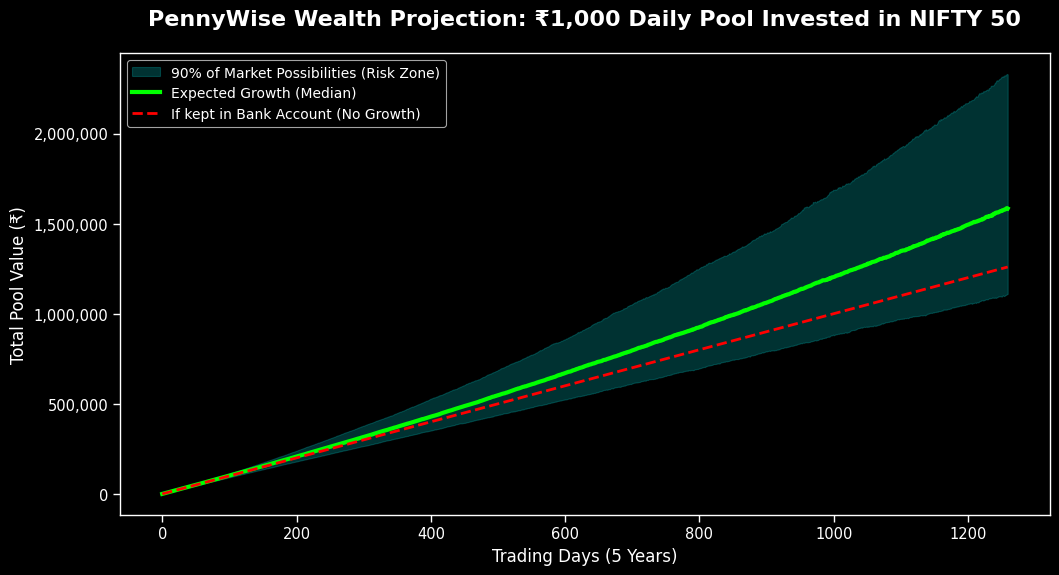

In [6]:
# [CELL 5] VISUALIZATION (THE FAN CHART)
plt.figure(figsize=(12, 6))

# Plot confidence intervals (The 'Fan')
days_array = np.arange(TRADING_DAYS)
plt.fill_between(days_array,
                 np.percentile(portfolio_paths, 5, axis=1),
                 np.percentile(portfolio_paths, 95, axis=1),
                 color='cyan', alpha=0.2, label="90% of Market Possibilities (Risk Zone)")

# Plot the Median line
plt.plot(days_array, np.percentile(portfolio_paths, 50, axis=1), color='#00FF00', linewidth=3, label="Expected Growth (Median)")

# Plot the "Under the Mattress" baseline (if they didn't invest)
baseline = np.array([DAILY_POOL * (i+1) for i in range(TRADING_DAYS)])
plt.plot(days_array, baseline, color='#FF0000', linewidth=2, linestyle='--', label="If kept in Bank Account (No Growth)")

plt.title("PennyWise Wealth Projection: ₹1,000 Daily Pool Invested in NIFTY 50", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Trading Days (5 Years)", fontsize=12)
plt.ylabel("Total Pool Value (₹)", fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.show()

In [7]:
# [CELL 6] THE "QUANT" RISK ANALYSIS
# Calculate 95% Value at Risk (VaR)
final_profits = final_values - total_money_invested
var_95 = np.percentile(final_profits, 5)

print("-" * 50)
print("🏦 ELITE QUANT METRICS FOR PORTFOLIO")
print("-" * 50)
print(f"95% Confidence Value at Risk (VaR): ₹{abs(var_95):,.2f}")
print("Interpretation: There is only a 5% chance the pool would lose more than this amount.")
print(f"Probability of Beating Cash: {(final_values > total_money_invested).mean()*100:.2f}%")
print("-" * 50)

--------------------------------------------------
🏦 ELITE QUANT METRICS FOR PORTFOLIO
--------------------------------------------------
95% Confidence Value at Risk (VaR): ₹149,198.80
Interpretation: There is only a 5% chance the pool would lose more than this amount.
Probability of Beating Cash: 85.68%
--------------------------------------------------


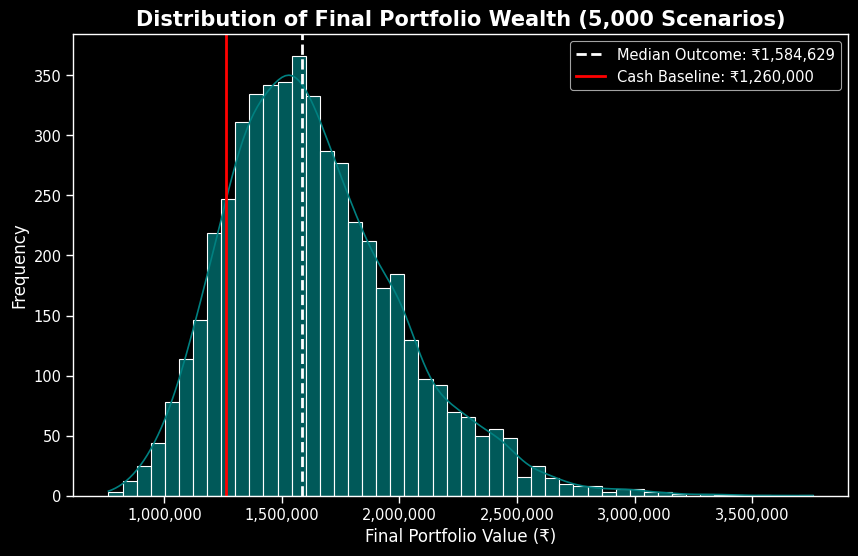

In [8]:
# [CELL 7] THE PROBABILITY DISTRIBUTION (Histogram)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Just in case it needs a reminder

plt.figure(figsize=(10, 6))

# This creates a 'Bell Curve' of your 5,000 simulations
sns.histplot(final_values, bins=50, kde=True, color='teal', alpha=0.7)

# Add a line for the 'Median' (the most likely result)
plt.axvline(np.percentile(final_values, 50), color='white', linestyle='--', linewidth=2, label=f'Median Outcome: ₹{np.percentile(final_values, 50):,.0f}')

# Add a line for your 'Baseline' (what they'd have if they didn't invest)
plt.axvline(total_money_invested, color='red', linestyle='-', linewidth=2, label=f'Cash Baseline: ₹{total_money_invested:,.0f}')

plt.title('Distribution of Final Portfolio Wealth (5,000 Scenarios)', fontsize=15, fontweight='bold')
plt.xlabel('Final Portfolio Value (₹)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()

# Formatting the numbers on the X-axis to be readable
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.show()